In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append('src')

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import ModelConfig

torch.manual_seed(1)
np.random.seed(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

os.makedirs('outputs', exist_ok=True)

from model import GraphSAGEModel, VASPDataProcessor, VASPTrainer, compute_class_distribution
from train import plot_training_history, plot_confusion_matrix, save_predictions, explain_prediction, create_simple_visualization

Using device: cpu


In [2]:
!python generate_data.py

Step 1: Generating scale-free graph...
Step 2: Assigning node features with structural risk...
Step 3: Adding preferential edges to form risky clusters...
Step 4: Adding edge features and exporting files...

--- Dataset generation complete ---
Generated graph with 3000 nodes and 75000 edges.


In [3]:
node_df = pd.read_csv("vasp_nodes.csv")
edge_df = pd.read_csv("vasp_edges.csv")

print(f"\nDataset Statistics:")
print(f"Nodes: {len(node_df)}")
print(f"Edges: {len(edge_df)}")
print(f"Node features: {node_df.columns.tolist()}")
print(f"Edge features: {edge_df.columns.tolist()}")


Dataset Statistics:
Nodes: 3000
Edges: 75000
Node features: ['risk_level', 'transaction_volume']
Edge features: ['source', 'target', 'fraud_ring_edge', 'timestamp', 'amount']


Risk Level Distribution:
  Low Risk (Class 0): 2063 (68.8%)
  Medium Risk (Class 1): 544 (18.1%)
  High Risk (Class 2): 393 (13.1%)


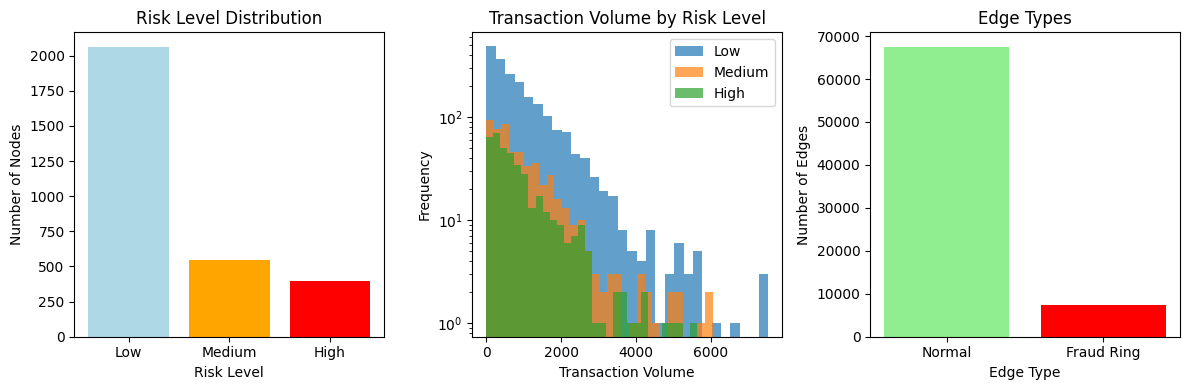

In [4]:
# Analyze the class distribution
risk_counts = node_df['risk_level'].value_counts().sort_index()
print("Risk Level Distribution:")
for risk_level, count in risk_counts.items():
    percentage = (count / len(node_df)) * 100
    risk_name = ['Low', 'Medium', 'High'][risk_level]
    print(f"  {risk_name} Risk (Class {risk_level}): {count} ({percentage:.1f}%)")

# Visualize class distribution
plt.figure(figsize=(12, 4))

# Class distribution
plt.subplot(1, 3, 1)
plt.bar(['Low', 'Medium', 'High'], risk_counts.values, color=['lightblue', 'orange', 'red'])
plt.title('Risk Level Distribution')
plt.ylabel('Number of Nodes')
plt.xlabel('Risk Level')

# Transaction volume distribution by risk level
plt.subplot(1, 3, 2)
for risk_level in [0, 1, 2]:
    volumes = node_df[node_df['risk_level'] == risk_level]['transaction_volume']
    plt.hist(volumes, bins=30, alpha=0.7, label=['Low', 'Medium', 'High'][risk_level])
plt.title('Transaction Volume by Risk Level')
plt.xlabel('Transaction Volume')
plt.ylabel('Frequency')
plt.legend()
plt.yscale('log')

# Fraud ring edges
fraud_edges = edge_df['fraud_ring_edge'].value_counts()
plt.subplot(1, 3, 3)
plt.bar(['Normal', 'Fraud Ring'], fraud_edges.values, color=['lightgreen', 'red'])
plt.title('Edge Types')
plt.ylabel('Number of Edges')
plt.xlabel('Edge Type')

plt.tight_layout()
plt.savefig('outputs/data_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Load and preprocess the data
print("Loading and preprocessing data...")
processor = VASPDataProcessor()
processor.load_graph()
data = processor.process_features()

# Display class distribution
compute_class_distribution(data.y.cpu().numpy())

# Create GraphSAGE model
print("\nCreating GraphSAGE model...")
input_dim = data.x.shape[1]
model = GraphSAGEModel(
    input_dim=input_dim,
    hidden_dim=128,
    output_dim=3,
    num_layers=3,
    dropout=0.5
)

print(f"Model architecture:")
print(f"  Input dimension: {input_dim}")
print(f"  Hidden dimension: 128")
print(f"  Output dimension: 3")
print(f"  Number of layers: 3")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Display model architecture
print("\nModel layers:")
for name, module in model.named_modules():
    if len(list(module.children())) == 0:  # Leaf modules only
        print(f"  {name}: {module}")

Loading and preprocessing data...
Loaded graph with 3000 nodes and 75000 edges
Processed data: 3000 nodes, 150000 edges
Node features shape: torch.Size([3000, 3])
Edge features shape: torch.Size([150000, 3])
Class Distribution:
  Low Risk (Class 0): 2063 (68.8%)
  Medium Risk (Class 1): 544 (18.1%)
  High Risk (Class 2): 393 (13.1%)

Creating GraphSAGE model...
Model architecture:
  Input dimension: 3
  Hidden dimension: 128
  Output dimension: 3
  Number of layers: 3
  Total parameters: 35,075

Model layers:
  convs.0.aggr_module: MeanAggregation()
  convs.0.lin_l: Linear(3, 128, bias=True)
  convs.0.lin_r: Linear(3, 128, bias=False)
  convs.1.aggr_module: MeanAggregation()
  convs.1.lin_l: Linear(128, 128, bias=True)
  convs.1.lin_r: Linear(128, 128, bias=False)
  convs.2.aggr_module: MeanAggregation()
  convs.2.lin_l: Linear(128, 3, bias=True)
  convs.2.lin_r: Linear(128, 3, bias=False)
  batch_norms.0: BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [6]:
# Initialize trainer
print("Initializing trainer...")
trainer = VASPTrainer(model, data, device=device)
trainer.create_data_splits(train_ratio=0.8, val_ratio=0.1, random_state=42)

# Display class weights (for handling imbalance)
unique, counts = np.unique(data.y.cpu().numpy(), return_counts=True)
class_weights = torch.tensor(len(data.y) / (len(unique) * counts), dtype=torch.float)
print(f"\nClass weights for imbalance handling:")
for i, (class_id, weight) in enumerate(zip(unique, class_weights)):
    risk_name = ['Low', 'Medium', 'High'][class_id]
    print(f"  {risk_name} Risk (Class {class_id}): {weight:.3f}")

# Train the model
print("\nStarting training...")
history = trainer.train(epochs=200, early_stopping_patience=25)

# Plot training history
plot_training_history(history)
plt.show()

print(f"\nTraining completed after {len(history['train_loss'])} epochs")
print(f"Best validation ROC-AUC: {max(history['val_roc_auc']):.4f}")
print(f"Best validation F1-Score: {max(history['val_f1']):.4f}")


Initializing trainer...
Train: 2400 nodes
Validation: 300 nodes
Test: 300 nodes

Class weights for imbalance handling:
  Low Risk (Class 0): 0.485
  Medium Risk (Class 1): 1.838
  High Risk (Class 2): 2.545

Starting training...
Epoch 0: Train Loss: 1.4852, Val Loss: 1.1022, Val F1: 0.0782, Val ROC-AUC: 0.7572
Epoch 10: Train Loss: 0.4896, Val Loss: 0.5412, Val F1: 0.6629, Val ROC-AUC: 0.7574
Epoch 20: Train Loss: 0.4660, Val Loss: 0.5187, Val F1: 0.6588, Val ROC-AUC: 0.7315
Epoch 30: Train Loss: 0.4614, Val Loss: 0.5003, Val F1: 0.6623, Val ROC-AUC: 0.7801
Epoch 40: Train Loss: 0.4584, Val Loss: 0.4954, Val F1: 0.6757, Val ROC-AUC: 0.7835
Epoch 50: Train Loss: 0.4606, Val Loss: 0.4946, Val F1: 0.6644, Val ROC-AUC: 0.7752
Epoch 60: Train Loss: 0.4531, Val Loss: 0.4924, Val F1: 0.6803, Val ROC-AUC: 0.7777
Epoch 70: Train Loss: 0.4590, Val Loss: 0.4922, Val F1: 0.6792, Val ROC-AUC: 0.7722
Epoch 80: Train Loss: 0.4576, Val Loss: 0.4931, Val F1: 0.6826, Val ROC-AUC: 0.7674
Early stopping a

In [7]:
# Evaluate on test set
print("Evaluating on test set...")
test_metrics = trainer.evaluate(trainer.test_mask)

print(f"\n=== TEST RESULTS ===")
print(f"Accuracy: {test_metrics['accuracy']}")
print(f"F1 Score (macro): {test_metrics['f1_score']}")
print(f"ROC-AUC (macro): {test_metrics['roc_auc']}")

# Check if ROC-AUC meets requirement
if test_metrics['roc_auc'] > 0.85:
    print("ROC-AUC requirement (>0.85) MET!")
else:
    print("ROC-AUC requirement (>0.85) not met")

# Detailed classification report
print("\n=== DETAILED CLASSIFICATION REPORT ===")
print(classification_report(
    test_metrics['true_labels'], 
    test_metrics['predictions'],
    target_names=['Low Risk', 'Medium Risk', 'High Risk']
))

# Plot confusion matrix
plot_confusion_matrix(test_metrics['true_labels'], test_metrics['predictions'])
plt.show()

# Save predictions
save_predictions(test_metrics, trainer.test_mask)

# Save final model
torch.save(model.state_dict(), 'outputs/model.pt')
print("\nModel saved to outputs/model.pt")
print("Predictions saved to outputs/predictions.csv")

Evaluating on test set...

=== TEST RESULTS ===
Accuracy: 0.5166666666666667
F1 Score (macro): 0.6126258272971515
ROC-AUC (macro): 0.7159691856473414
ROC-AUC requirement (>0.85) not met

=== DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Low Risk       0.75      0.45      0.56       206
 Medium Risk       0.20      0.47      0.28        59
   High Risk       1.00      1.00      1.00        35

    accuracy                           0.52       300
   macro avg       0.65      0.64      0.61       300
weighted avg       0.67      0.52      0.56       300

Confusion matrix saved to outputs/confusion_matrix.png
Predictions saved to outputs/predictions.csv

Model saved to outputs/model.pt
Predictions saved to outputs/predictions.csv


Found 35 correctly predicted high-risk nodes
Explaining prediction for node 4
Node 4 details:
  True risk level: High
  Predicted risk level: High
  Prediction probabilities: Low=0.000, Medium=0.000, High=1.000
Explanation visualization saved to outputs/explanation.png
GNN explanation generated for node 4


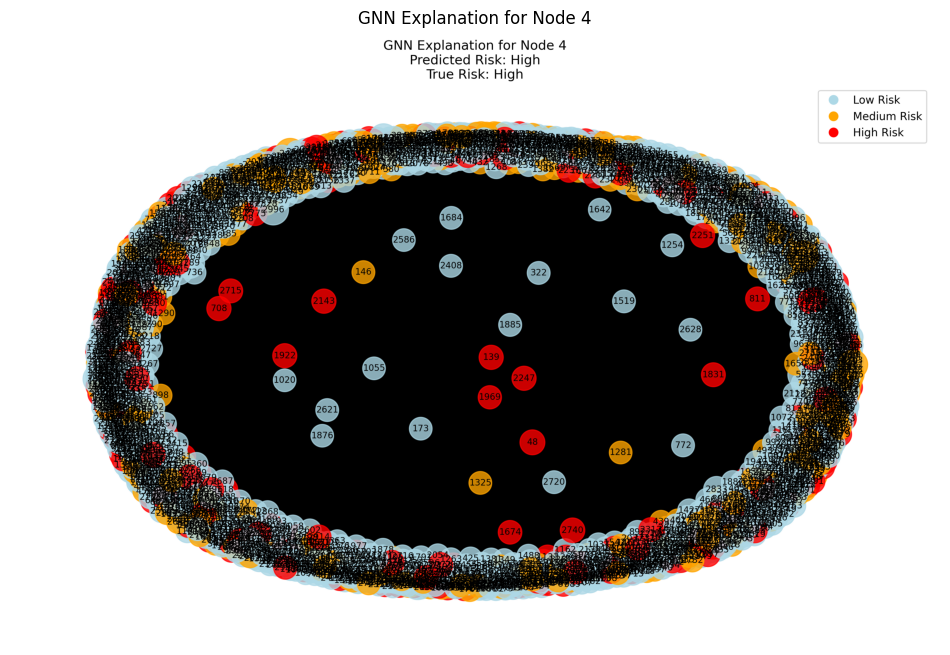

Simple visualization saved to outputs/simple_explanation.png

=== Model explanation completed! ===


In [8]:
# Find a high-risk node that was correctly predicted
high_risk_correct = []
for i, (true_label, pred_label) in enumerate(zip(test_metrics['true_labels'], test_metrics['predictions'])):
    if true_label == 2 and pred_label == 2:  # High risk correctly predicted
        test_indices = torch.where(trainer.test_mask)[0].cpu().numpy()
        high_risk_correct.append(test_indices[i])

print(f"Found {len(high_risk_correct)} correctly predicted high-risk nodes")

if high_risk_correct:
    # Select the first correctly predicted high-risk node
    target_node = high_risk_correct[0]
    print(f"Explaining prediction for node {target_node}")
    
    # Get model prediction for this node
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index, data.edge_attr)
        pred_probs = F.softmax(logits[target_node], dim=0)
        pred_class = logits[target_node].argmax().item()
        true_class = data.y[target_node].item()
    
    print(f"Node {target_node} details:")
    print(f"  True risk level: {['Low', 'Medium', 'High'][true_class]}")
    print(f"  Predicted risk level: {['Low', 'Medium', 'High'][pred_class]}")
    print(f"  Prediction probabilities: Low={pred_probs[0]:.3f}, Medium={pred_probs[1]:.3f}, High={pred_probs[2]:.3f}")
    
    # Create explainer
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=200),
        explanation_type='model',
        model_config=ModelConfig(
            mode='multiclass_classification',
            task_level='node',
            return_type='probs'
        ),
        node_mask_type='attributes',
        edge_mask_type='object'
    )
    
    explain_prediction(model, data, explainer, target_node)
    print(f"GNN explanation generated for node {target_node}")
    
    # Display the explanation visualization
    img = plt.imread('outputs/explanation.png')
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'GNN Explanation for Node {target_node}')
    plt.show()
        
    print("Simple visualization saved to outputs/simple_explanation.png")

print("\n=== Model explanation completed! ===")


Simple visualization saved to outputs/simple_explanation.png


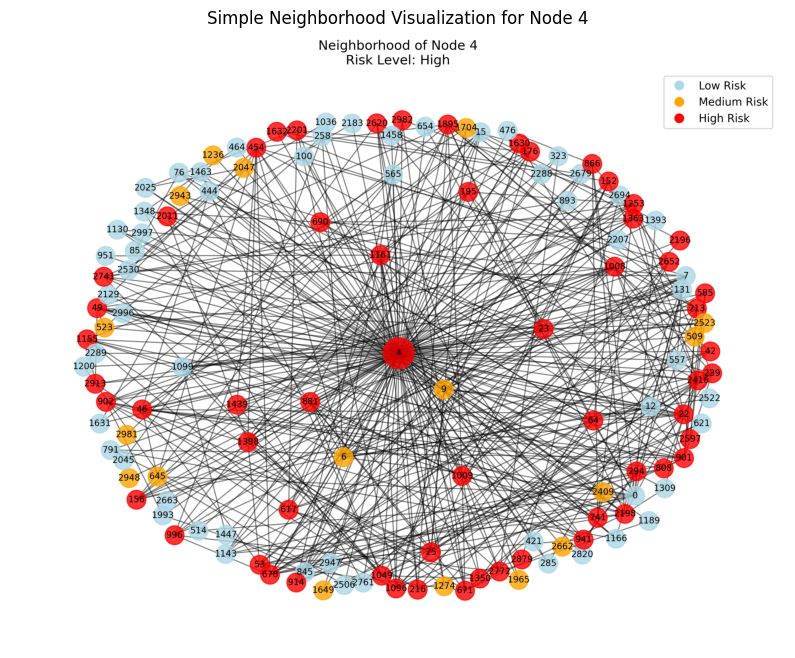

In [9]:
# Call the function with the required arguments: data, node_idx, and optionally save_path
create_simple_visualization(data, target_node, save_path='outputs/simple_explanation.png')
img = plt.imread('outputs/simple_explanation.png')
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f'Simple Neighborhood Visualization for Node {target_node}')
plt.show()